In [367]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("Environment ready.")

Python executable: c:\ProgramData\miniforge3\envs\astar-costmap\python.exe
NumPy version: 2.4.6
Environment ready.


# Synthetic Driving Scene Generation

This notebook generates simplified bird's-eye-view grid maps for the
CNN-guided A* path-planning project.

Each scene contains:

1. Drivable-area mask
2. Obstacle mask
3. Lane-center preference map
4. Start-point map
5. Goal-point map

In [368]:
from dataclasses import dataclass
from collections import deque
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

## 1. Scene Data Structure

Each synthetic scene stores five input channels together with the
start and goal coordinates.

In [369]:
@dataclass
class DrivingScene:
    """A synthetic bird's-eye-view driving scene."""

    # Five input channels
    road_mask: np.ndarray
    obstacle_mask: np.ndarray
    lane_center_map: np.ndarray
    start_map: np.ndarray
    goal_map: np.ndarray

    # Start and goal coordinates: (row, column)
    start: tuple[int, int]
    goal: tuple[int, int]

    # Horizontal position of the road center at every row
    centerline_x: np.ndarray

    @property
    def free_space(self) -> np.ndarray:
        """
        Return cells that are inside the road and not occupied
        by obstacles.
        """
        return self.road_mask & (~self.obstacle_mask)

    @property
    def model_input(self) -> np.ndarray:
        """
        Combine the five maps into one CNN input tensor.

        Output shape:
            (5, height, width)
        """
        return np.stack(
            [
                self.road_mask.astype(np.float32),
                self.obstacle_mask.astype(np.float32),
                self.lane_center_map.astype(np.float32),
                self.start_map.astype(np.float32),
                self.goal_map.astype(np.float32),
            ],
            axis=0,
        )

In [370]:
def make_gaussian_point_map(
    height: int,
    width: int,
    point: tuple[int, int],
    sigma: float = 1.5,
) -> np.ndarray:
    """
    Create a Gaussian heatmap centered at a grid point.

    Args:
        height: Number of rows.
        width: Number of columns.
        point: Center point in (row, column) format.
        sigma: Controls the width of the Gaussian region.

    Returns:
        Heatmap with shape (height, width).
    """
    row, col = point

    yy, xx = np.meshgrid(
        np.arange(height),
        np.arange(width),
        indexing="ij",
    )

    squared_distance = (
        (yy - row) ** 2
        + (xx - col) ** 2
    )

    heatmap = np.exp(
        -squared_distance / (2.0 * sigma**2)
    )

    return heatmap.astype(np.float32)

Shape: (64, 64)
Maximum value: 1.0
Maximum position: (np.int64(50), np.int64(32))


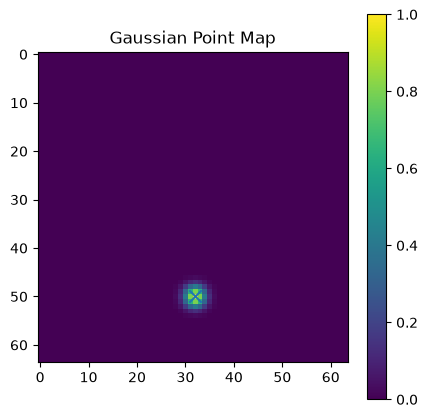

In [371]:
test_map = make_gaussian_point_map(
    height=64,
    width=64,
    point=(50, 32),
    sigma=1.5,
)

print("Shape:", test_map.shape)
print("Maximum value:", test_map.max())
print("Maximum position:", np.unravel_index(
    np.argmax(test_map),
    test_map.shape,
))

plt.figure(figsize=(5, 5))
plt.imshow(test_map)
plt.title("Gaussian Point Map")
plt.scatter(32, 50, marker="x", s=80)
plt.colorbar()
plt.show()

## 2. Path-Existence Check

A breadth-first search is used to verify that each randomly generated
scene contains at least one collision-free path from the start to the goal.

In [372]:
def path_exists(
    free_space: np.ndarray,
    start: tuple[int, int],
    goal: tuple[int, int],
) -> bool:
    """
    Check whether a collision-free path exists using breadth-first search.

    The grid uses 8-connected movement:
    horizontal, vertical, and diagonal moves.

    Diagonal corner cutting is not allowed.

    Args:
        free_space:
            Boolean array where True indicates a traversable cell.
        start:
            Start coordinate in (row, column) format.
        goal:
            Goal coordinate in (row, column) format.

    Returns:
        True if a valid path exists; otherwise False.
    """
    height, width = free_space.shape

    start_row, start_col = start
    goal_row, goal_col = goal

    # Check whether start and goal are inside the map.
    start_inside = (
        0 <= start_row < height
        and 0 <= start_col < width
    )

    goal_inside = (
        0 <= goal_row < height
        and 0 <= goal_col < width
    )

    if not start_inside or not goal_inside:
        return False

    # Start and goal must both be traversable.
    if not free_space[start]:
        return False

    if not free_space[goal]:
        return False

    movements = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1),    # right
        (-1, -1),  # upper-left
        (-1, 1),   # upper-right
        (1, -1),   # lower-left
        (1, 1),    # lower-right
    ]

    visited = np.zeros_like(
        free_space,
        dtype=bool,
    )

    visited[start] = True
    queue = deque([start])

    while queue:
        current_row, current_col = queue.popleft()

        if (current_row, current_col) == goal:
            return True

        for delta_row, delta_col in movements:
            next_row = current_row + delta_row
            next_col = current_col + delta_col

            inside_map = (
                0 <= next_row < height
                and 0 <= next_col < width
            )

            if not inside_map:
                continue

            if visited[next_row, next_col]:
                continue

            if not free_space[next_row, next_col]:
                continue

            # Prevent diagonal movement through obstacle corners.
            is_diagonal = (
                delta_row != 0
                and delta_col != 0
            )

            if is_diagonal:
                adjacent_vertical = (
                    current_row + delta_row,
                    current_col,
                )

                adjacent_horizontal = (
                    current_row,
                    current_col + delta_col,
                )

                if (
                    not free_space[adjacent_vertical]
                    or not free_space[adjacent_horizontal]
                ):
                    continue

            visited[next_row, next_col] = True
            queue.append((next_row, next_col))

    return False

In [373]:
# Create a small test map.
test_free_space = np.ones(
    (10, 10),
    dtype=bool,
)

test_start = (8, 2)
test_goal = (1, 7)

print(
    "Open map:",
    path_exists(
        test_free_space,
        test_start,
        test_goal,
    ),
)

# Add a complete horizontal wall.
blocked_free_space = test_free_space.copy()
blocked_free_space[5, :] = False

print(
    "Blocked map:",
    path_exists(
        blocked_free_space,
        test_start,
        test_goal,
    ),
)

Open map: True
Blocked map: False


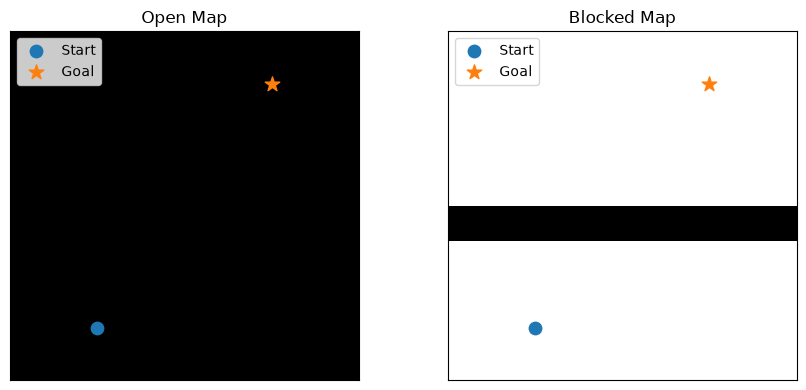

In [374]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
)

test_cases = [
    ("Open Map", test_free_space),
    ("Blocked Map", blocked_free_space),
]

for axis, (title, free_space) in zip(
    axes,
    test_cases,
):
    axis.imshow(
        free_space,
        cmap="gray",
        origin="upper",
    )

    axis.scatter(
        test_start[1],
        test_start[0],
        marker="o",
        s=80,
        label="Start",
    )

    axis.scatter(
        test_goal[1],
        test_goal[0],
        marker="*",
        s=120,
        label="Goal",
    )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend()

plt.tight_layout()
plt.show()

## 3. Synthetic Driving Scene Generator

This section generates a slightly curved road, randomly places static
obstacles, and rejects maps in which no valid start-to-goal path exists.

In [375]:
def generate_driving_scene(
    seed: Optional[int] = None,
    height: int = 64,
    width: int = 64,
    road_half_width: int = 10,
    min_obstacles: int = 2,
    max_obstacles: int = 5,
    max_generation_attempts: int = 100,
) -> DrivingScene:
    """
    Generate one valid synthetic driving-like grid scene.

    A valid scene must satisfy:
    1. Start and goal are inside the drivable road.
    2. Start and goal are not occupied by obstacles.
    3. At least one collision-free path exists.

    Args:
        seed:
            Random seed for reproducibility.
        height:
            Number of grid rows.
        width:
            Number of grid columns.
        road_half_width:
            Distance from the centerline to each road boundary.
        min_obstacles:
            Minimum number of rectangular obstacles.
        max_obstacles:
            Maximum number of rectangular obstacles.
        max_generation_attempts:
            Maximum number of obstacle-layout retries.

    Returns:
        A valid DrivingScene.

    Raises:
        RuntimeError:
            If no valid scene is found after all attempts.
    """
    rng = np.random.default_rng(seed)

    # Coordinate grids.
    yy, xx = np.meshgrid(
        np.arange(height),
        np.arange(width),
        indexing="ij",
    )

    for attempt in range(max_generation_attempts):

        # ---------------------------------------------------------
        # 1. Generate a slightly curved road centerline.
        # ---------------------------------------------------------
        normalized_row = (
            np.arange(height)
            / max(height - 1, 1)
        )

        curve_amplitude = rng.uniform(1.0, 5.0)
        curve_phase = rng.uniform(
            0.0,
            2.0 * np.pi,
        )

        centerline_x = (
            width / 2
            + curve_amplitude
            * np.sin(
                np.pi * normalized_row
                + curve_phase
            )
        )

        # centerline_x has shape (height,).
        # Convert it to (height, 1) for broadcasting.
        centerline_grid = centerline_x[:, None]

        distance_to_centerline = np.abs(
            xx - centerline_grid
        )

        road_mask = (
            distance_to_centerline
            <= road_half_width
        )

        # ---------------------------------------------------------
        # 2. Place start and goal near the road center.
        # ---------------------------------------------------------
        start_row = height - 3
        goal_row = 2

        start_col = int(
            np.clip(
                round(centerline_x[start_row]),
                0,
                width - 1,
            )
        )

        goal_col = int(
            np.clip(
                round(centerline_x[goal_row]),
                0,
                width - 1,
            )
        )

        start = (start_row, start_col)
        goal = (goal_row, goal_col)

        # ---------------------------------------------------------
        # 3. Randomly generate rectangular obstacles.
        # ---------------------------------------------------------
        obstacle_mask = np.zeros(
            (height, width),
            dtype=bool,
        )

        number_of_obstacles = int(
            rng.integers(
                min_obstacles,
                max_obstacles + 1,
            )
        )

        for _ in range(number_of_obstacles):

            obstacle_height = int(
                rng.integers(3, 8)
            )

            obstacle_width = int(
                rng.integers(3, 7)
            )

            # Keep obstacles away from the top and bottom.
            obstacle_center_row = int(
                rng.integers(
                    8,
                    height - 8,
                )
            )

            local_centerline = centerline_x[
                obstacle_center_row
            ]

            lateral_offset = rng.uniform(
                -road_half_width + 3,
                road_half_width - 3,
            )

            obstacle_center_col = int(
                round(
                    local_centerline
                    + lateral_offset
                )
            )

            row_min = max(
                0,
                obstacle_center_row
                - obstacle_height // 2,
            )

            row_max = min(
                height,
                row_min + obstacle_height,
            )

            col_min = max(
                0,
                obstacle_center_col
                - obstacle_width // 2,
            )

            col_max = min(
                width,
                col_min + obstacle_width,
            )

            proposed_obstacle = np.zeros(
                (height, width),
                dtype=bool,
            )

            proposed_obstacle[
                row_min:row_max,
                col_min:col_max,
            ] = True

            # Obstacles may occupy only road cells.
            proposed_obstacle &= road_mask

            # Keep a clear region around the start.
            proposed_obstacle[
                max(0, start_row - 5):
                min(height, start_row + 6),
                max(0, start_col - 5):
                min(width, start_col + 6),
            ] = False

            # Keep a clear region around the goal.
            proposed_obstacle[
                max(0, goal_row - 5):
                min(height, goal_row + 6),
                max(0, goal_col - 5):
                min(width, goal_col + 6),
            ] = False

            obstacle_mask |= proposed_obstacle

        # ---------------------------------------------------------
        # 4. Verify that a valid path exists.
        # ---------------------------------------------------------
        free_space = (
            road_mask
            & (~obstacle_mask)
        )

        if not path_exists(
            free_space=free_space,
            start=start,
            goal=goal,
        ):
            continue

        # ---------------------------------------------------------
        # 5. Construct the lane-center preference map.
        # ---------------------------------------------------------
        lane_sigma = 2.0

        lane_center_map = np.exp(
            -(
                distance_to_centerline**2
            )
            / (
                2.0 * lane_sigma**2
            )
        )

        # Preference exists only inside the road.
        lane_center_map *= road_mask

        lane_center_map = (
            lane_center_map.astype(
                np.float32
            )
        )

        # ---------------------------------------------------------
        # 6. Construct start and goal heatmaps.
        # ---------------------------------------------------------
        start_map = make_gaussian_point_map(
            height=height,
            width=width,
            point=start,
            sigma=1.5,
        )

        goal_map = make_gaussian_point_map(
            height=height,
            width=width,
            point=goal,
            sigma=1.5,
        )

        return DrivingScene(
            road_mask=road_mask,
            obstacle_mask=obstacle_mask,
            lane_center_map=lane_center_map,
            start_map=start_map,
            goal_map=goal_map,
            start=start,
            goal=goal,
            centerline_x=centerline_x,
        )

    raise RuntimeError(
        "Unable to generate a valid scene after "
        f"{max_generation_attempts} attempts."
    )

In [376]:
scene = generate_driving_scene(
    seed=4,
)

print(
    "Road mask shape:",
    scene.road_mask.shape,
)

print(
    "Obstacle mask shape:",
    scene.obstacle_mask.shape,
)

print(
    "Model input shape:",
    scene.model_input.shape,
)

print(
    "Start:",
    scene.start,
)

print(
    "Goal:",
    scene.goal,
)

print(
    "Number of obstacle cells:",
    scene.obstacle_mask.sum(),
)

print(
    "Valid path exists:",
    path_exists(
        free_space=scene.free_space,
        start=scene.start,
        goal=scene.goal,
    ),
)

Road mask shape: (64, 64)
Obstacle mask shape: (64, 64)
Model input shape: (5, 64, 64)
Start: (61, 32)
Goal: (2, 31)
Number of obstacle cells: 120
Valid path exists: True


## 4. Scene Visualization

The five channels are visualized separately, together with a combined
bird's-eye-view representation of the scene.

In [377]:
def plot_scene_channels(
    scene: DrivingScene,
) -> None:
    """
    Visualize the five CNN input channels and the combined scene.
    """
    channel_names = [
        "Drivable Area",
        "Obstacle Mask",
        "Lane-Center Preference",
        "Start Map",
        "Goal Map",
    ]

    channels = scene.model_input

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(13, 8),
    )

    axes = axes.ravel()

    # Plot the five separate channels.
    for index in range(5):
        image = axes[index].imshow(
            channels[index],
            origin="upper",
        )

        axes[index].set_title(
            channel_names[index]
        )

        axes[index].set_xticks([])
        axes[index].set_yticks([])

        fig.colorbar(
            image,
            ax=axes[index],
            fraction=0.046,
            pad=0.04,
        )

    # Plot the combined scene.
    axes[5].imshow(
        scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    obstacle_overlay = np.ma.masked_where(
        ~scene.obstacle_mask,
        scene.obstacle_mask,
    )

    axes[5].imshow(
        obstacle_overlay,
        cmap="Reds",
        alpha=0.9,
        origin="upper",
    )

    axes[5].plot(
        scene.centerline_x,
        np.arange(
            scene.road_mask.shape[0]
        ),
        linestyle="--",
        linewidth=1.5,
        label="Lane center",
    )

    axes[5].scatter(
        scene.start[1],
        scene.start[0],
        marker="o",
        s=80,
        label="Start",
    )

    axes[5].scatter(
        scene.goal[1],
        scene.goal[0],
        marker="*",
        s=130,
        label="Goal",
    )

    axes[5].set_title(
        "Combined Scene"
    )

    axes[5].set_xlim(
        0,
        scene.road_mask.shape[1] - 1,
    )

    axes[5].set_ylim(
        scene.road_mask.shape[0] - 1,
        0,
    )

    axes[5].set_aspect("equal")

    axes[5].legend(
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()

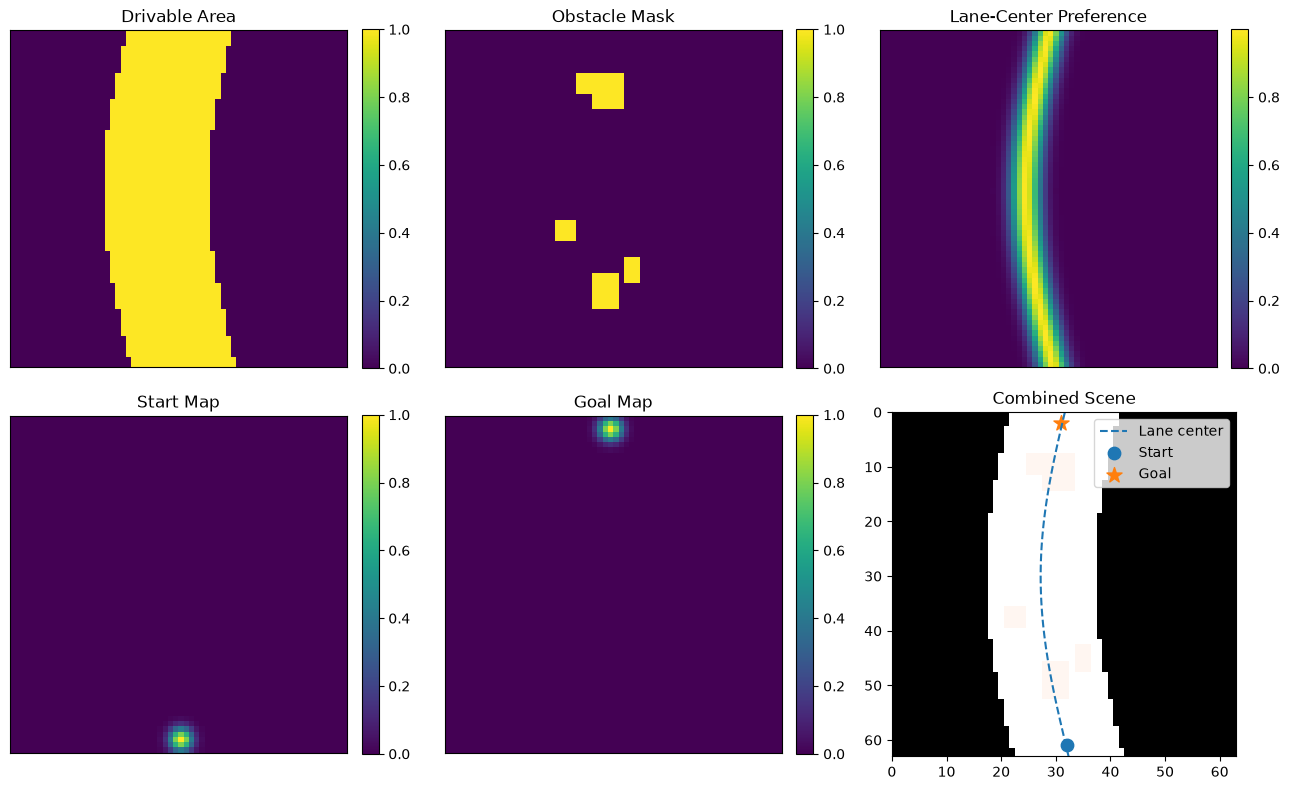

In [378]:
plot_scene_channels(scene)

## 5. Multiple-Scene Inspection

Several scenes are generated with different random seeds to inspect
the diversity and validity of the procedural map generator.

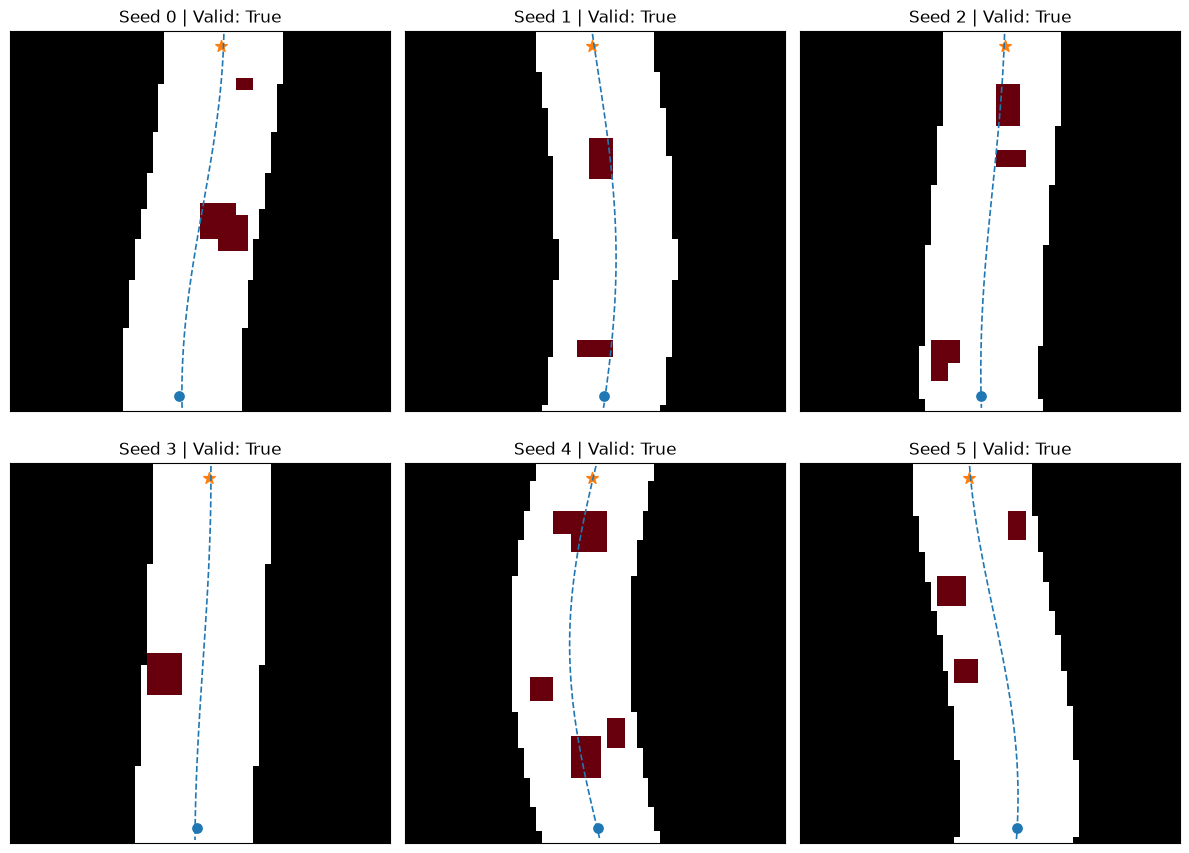

In [379]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 9),
)

axes = axes.ravel()

for index, seed in enumerate(range(6)):
    sample_scene = generate_driving_scene(seed=seed)

    # Outside the road is dark; drivable road is light.
    axes[index].imshow(
        sample_scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    # Show obstacles clearly.
    obstacle_overlay = np.ma.masked_where(
        ~sample_scene.obstacle_mask,
        sample_scene.obstacle_mask,
    )

    axes[index].imshow(
        obstacle_overlay,
        cmap="Reds",
        vmin=0,
        vmax=1,
        alpha=1.0,
        origin="upper",
    )

    # Road centerline.
    axes[index].plot(
        sample_scene.centerline_x,
        np.arange(sample_scene.road_mask.shape[0]),
        linestyle="--",
        linewidth=1.2,
        label="Lane center",
    )

    # Start and goal.
    axes[index].scatter(
        sample_scene.start[1],
        sample_scene.start[0],
        marker="o",
        s=45,
        label="Start",
    )

    axes[index].scatter(
        sample_scene.goal[1],
        sample_scene.goal[0],
        marker="*",
        s=75,
        label="Goal",
    )

    valid = path_exists(
        sample_scene.free_space,
        sample_scene.start,
        sample_scene.goal,
    )

    axes[index].set_title(
        f"Seed {seed} | Valid: {valid}"
    )

    axes[index].set_xticks([])
    axes[index].set_yticks([])
    axes[index].set_aspect("equal")

plt.tight_layout()
plt.show()

In [380]:
number_of_test_scenes = 100
valid_scene_count = 0

for seed in range(number_of_test_scenes):
    test_scene = generate_driving_scene(seed=seed)

    valid = path_exists(
        test_scene.free_space,
        test_scene.start,
        test_scene.goal,
    )

    if valid:
        valid_scene_count += 1

print(
    f"Valid scenes: "
    f"{valid_scene_count}/{number_of_test_scenes}"
)

Valid scenes: 100/100


## 6. Standard A* Path Planning

A standard A* planner is implemented on the 8-connected grid.
The planner returns the path, path length, number of expanded nodes,
planning time, and success status.

In [381]:
import heapq
import time
from dataclasses import dataclass

In [382]:
@dataclass
class AStarResult:
    path: list[tuple[int, int]]
    path_length: float
    expanded_nodes: int
    planning_time: float
    success: bool

In [383]:
def octile_distance(
    current: tuple[int, int],
    goal: tuple[int, int],
) -> float:
    """
    Octile-distance heuristic for an 8-connected grid.
    """
    row_difference = abs(current[0] - goal[0])
    col_difference = abs(current[1] - goal[1])

    diagonal_moves = min(
        row_difference,
        col_difference,
    )

    straight_moves = max(
        row_difference,
        col_difference,
    ) - diagonal_moves

    return (
        np.sqrt(2.0) * diagonal_moves
        + straight_moves
    )

In [384]:
def reconstruct_path(
    came_from: dict[
        tuple[int, int],
        tuple[int, int],
    ],
    goal: tuple[int, int],
) -> list[tuple[int, int]]:
    """
    Reconstruct the path from goal to start.
    """
    path = [goal]
    current = goal

    while current in came_from:
        current = came_from[current]
        path.append(current)

    path.reverse()

    return path

In [385]:
def astar_search(
    free_space: np.ndarray,
    start: tuple[int, int],
    goal: tuple[int, int],
) -> AStarResult:
    """
    Perform standard A* search on an 8-connected grid.

    Diagonal corner cutting is not allowed.
    """
    start_time = time.perf_counter()

    height, width = free_space.shape

    if not free_space[start] or not free_space[goal]:
        return AStarResult(
            path=[],
            path_length=np.inf,
            expanded_nodes=0,
            planning_time=time.perf_counter() - start_time,
            success=False,
        )

    movements = [
        (-1, 0, 1.0),
        (1, 0, 1.0),
        (0, -1, 1.0),
        (0, 1, 1.0),
        (-1, -1, np.sqrt(2.0)),
        (-1, 1, np.sqrt(2.0)),
        (1, -1, np.sqrt(2.0)),
        (1, 1, np.sqrt(2.0)),
    ]

    open_heap = []

    heapq.heappush(
        open_heap,
        (
            octile_distance(start, goal),
            0.0,
            start,
        ),
    )

    came_from = {}

    g_cost = {
        start: 0.0,
    }

    closed_set = set()
    expanded_nodes = 0

    while open_heap:
        current_f, current_g, current = heapq.heappop(
            open_heap
        )

        if current in closed_set:
            continue

        closed_set.add(current)
        expanded_nodes += 1

        if current == goal:
            path = reconstruct_path(
                came_from,
                goal,
            )

            return AStarResult(
                path=path,
                path_length=g_cost[goal],
                expanded_nodes=expanded_nodes,
                planning_time=time.perf_counter()
                - start_time,
                success=True,
            )

        current_row, current_col = current

        for (
            delta_row,
            delta_col,
            movement_cost,
        ) in movements:

            next_row = current_row + delta_row
            next_col = current_col + delta_col

            inside_map = (
                0 <= next_row < height
                and 0 <= next_col < width
            )

            if not inside_map:
                continue

            neighbor = (
                next_row,
                next_col,
            )

            if not free_space[neighbor]:
                continue

            is_diagonal = (
                delta_row != 0
                and delta_col != 0
            )

            if is_diagonal:
                adjacent_vertical = (
                    current_row + delta_row,
                    current_col,
                )

                adjacent_horizontal = (
                    current_row,
                    current_col + delta_col,
                )

                if (
                    not free_space[adjacent_vertical]
                    or not free_space[adjacent_horizontal]
                ):
                    continue

            tentative_g = (
                g_cost[current]
                + movement_cost
            )

            if tentative_g >= g_cost.get(
                neighbor,
                np.inf,
            ):
                continue

            came_from[neighbor] = current
            g_cost[neighbor] = tentative_g

            heuristic = octile_distance(
                neighbor,
                goal,
            )

            total_cost = (
                tentative_g
                + heuristic
            )

            heapq.heappush(
                open_heap,
                (
                    total_cost,
                    tentative_g,
                    neighbor,
                ),
            )

    return AStarResult(
        path=[],
        path_length=np.inf,
        expanded_nodes=expanded_nodes,
        planning_time=time.perf_counter()
        - start_time,
        success=False,
    )

In [386]:
astar_result = astar_search(
    free_space=scene.free_space,
    start=scene.start,
    goal=scene.goal,
)

print("Success:", astar_result.success)
print("Path length:", astar_result.path_length)
print("Expanded nodes:", astar_result.expanded_nodes)
print(
    "Planning time:",
    f"{astar_result.planning_time * 1000:.3f} ms",
)
print("Number of path cells:", len(astar_result.path))

Success: True
Path length: 61.07106781186546
Expanded nodes: 164
Planning time: 0.701 ms
Number of path cells: 60


## 7. Standard A* Path Visualization

The standard A* path is overlaid on the generated driving scene to
verify collision avoidance and path connectivity.

In [387]:
def plot_astar_path(
    scene: DrivingScene,
    result: AStarResult,
    title: str = "Standard A* Path",
) -> None:
    """
    Plot an A* result on top of a driving scene.
    """
    fig, ax = plt.subplots(
        figsize=(7, 7),
    )

    # Road area.
    ax.imshow(
        scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    # Obstacles.
    obstacle_overlay = np.ma.masked_where(
        ~scene.obstacle_mask,
        scene.obstacle_mask,
    )

    ax.imshow(
        obstacle_overlay,
        cmap="Reds",
        vmin=0,
        vmax=1,
        alpha=1.0,
        origin="upper",
    )

    # Lane centerline.
    ax.plot(
        scene.centerline_x,
        np.arange(scene.road_mask.shape[0]),
        linestyle="--",
        linewidth=1.5,
        label="Lane center",
    )

    # Planned path.
    if result.success and result.path:
        path_array = np.asarray(result.path)

        path_rows = path_array[:, 0]
        path_cols = path_array[:, 1]

        ax.plot(
            path_cols,
            path_rows,
            linewidth=2.5,
            label="Standard A* path",
        )

    # Start and goal.
    ax.scatter(
        scene.start[1],
        scene.start[0],
        marker="o",
        s=100,
        edgecolors="black",
        label="Start",
        zorder=5,
    )

    ax.scatter(
        scene.goal[1],
        scene.goal[0],
        marker="*",
        s=180,
        edgecolors="black",
        label="Goal",
        zorder=5,
    )

    status_text = (
        f"Success: {result.success}\n"
        f"Length: {result.path_length:.2f}\n"
        f"Expanded nodes: {result.expanded_nodes}\n"
        f"Planning time: {result.planning_time * 1000:.3f} ms"
    )

    ax.text(
        0.02,
        0.02,
        status_text,
        transform=ax.transAxes,
        verticalalignment="bottom",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

    ax.set_title(title)
    ax.set_xlim(0, scene.road_mask.shape[1] - 1)
    ax.set_ylim(scene.road_mask.shape[0] - 1, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Grid column")
    ax.set_ylabel("Grid row")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

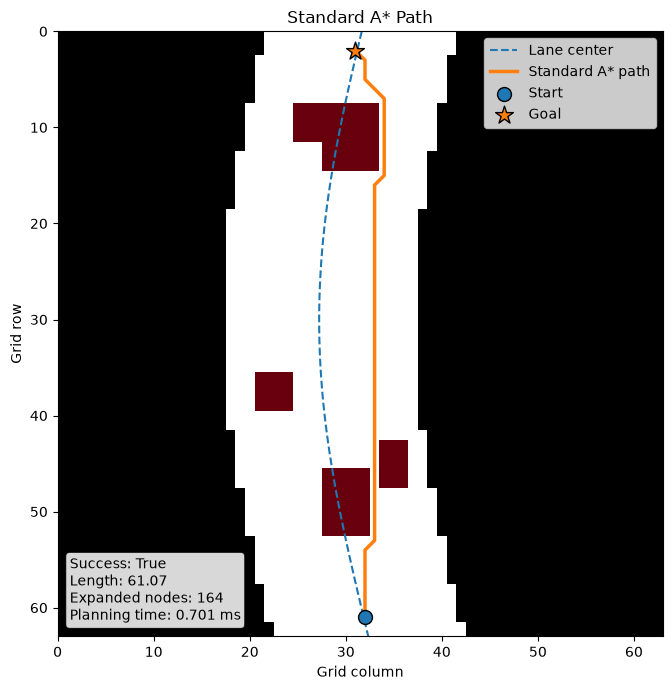

In [388]:
plot_astar_path(
    scene=scene,
    result=astar_result,
)

In [389]:
def validate_path(
    free_space: np.ndarray,
    path: list[tuple[int, int]],
    start: tuple[int, int],
    goal: tuple[int, int],
) -> bool:
    """
    Verify that a planned path is connected and collision-free.
    """
    if not path:
        return False

    if path[0] != start:
        return False

    if path[-1] != goal:
        return False

    height, width = free_space.shape

    for index, current in enumerate(path):
        row, col = current

        if not (
            0 <= row < height
            and 0 <= col < width
        ):
            return False

        if not free_space[current]:
            return False

        if index == 0:
            continue

        previous_row, previous_col = path[index - 1]

        row_difference = abs(row - previous_row)
        col_difference = abs(col - previous_col)

        # Consecutive cells must be 8-connected.
        if max(row_difference, col_difference) != 1:
            return False

        # Prevent diagonal corner cutting.
        is_diagonal = (
            row_difference == 1
            and col_difference == 1
        )

        if is_diagonal:
            if (
                not free_space[row, previous_col]
                or not free_space[previous_row, col]
            ):
                return False

    return True

In [390]:
path_is_valid = validate_path(
    free_space=scene.free_space,
    path=astar_result.path,
    start=scene.start,
    goal=scene.goal,
)

print("Path is valid:", path_is_valid)

Path is valid: True
